In [1]:
import os
import pickle
import sys

import numpy as np
import torch

root_dir = os.path.abspath("..")
data_dir = os.path.join(root_dir, "data")
os.makedirs(data_dir, exist_ok=True)
if root_dir not in sys.path:
    sys.path.append(root_dir)

from current_setpoints.parameters import Flux_IEEEMachine2, IEEEMachine2
from current_setpoints.simulation import Transform
from current_setpoints.optimization import (
    ModelAnalytical,
    ModelNeural,
    MotorOptimizer,
    calculate_grid,
    get_correction_grid,
    grid_to_data,
)
from current_setpoints.utils.neural import load_neural_model
from current_setpoints.utils.plotting import plot_grid_segments

In [2]:
flux = Flux_IEEEMachine2()
machine = IEEEMachine2()

NMAX = 1800  # mechanical RPM
machine.set_max_pars(curr_max=30.0, volt_max=13.0, omega_max=NMAX)
transform = Transform(machine=machine, flux=flux, add_volt_0=False)

analytical_model = ModelAnalytical(machine=machine, flux=flux)
solver_opts = {"disp": False, "ftol": 1e-8, "maxiter": 500, "eps": 1e-8}
optimizer = MotorOptimizer(model=analytical_model, opts=solver_opts)

grid_opts = {"n_torq": 201, "n_omega": 201, "torq_min": 0.0, "omega_min": 0.0}

Loading existing baseline grid from 'c:\Users\matas\Desktop\CurrentSetpoints_main\data\IEEETIE_machine2_baseline.pkl'...
Plotting baseline grid...


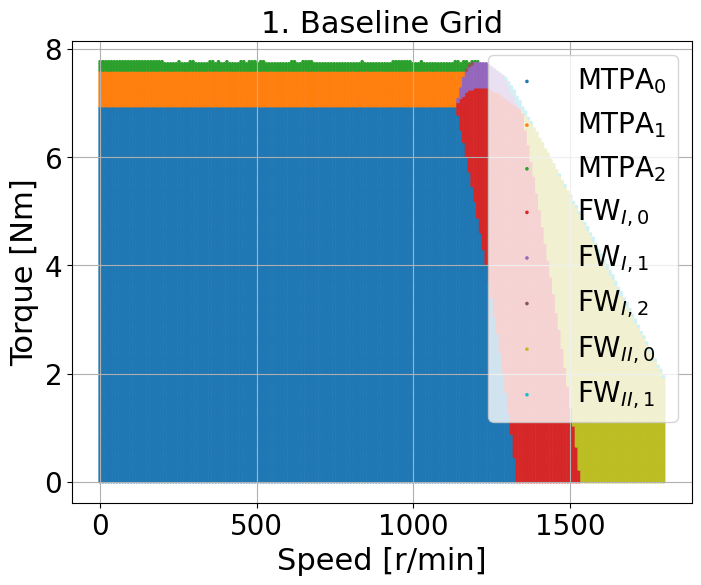

In [3]:
# 1. Baseline grid: analytical optimum at every (T, omega) operating point.
filename = os.path.join(data_dir, "IEEETIE_machine2_baseline.pkl")

if os.path.isfile(filename):
    print(f"Loading existing baseline grid from '{filename}'...")
    with open(filename, "rb") as file:
        grid_result = pickle.load(file)
else:
    print("Starting baseline grid calculation. This may take a few minutes...")
    grid_result = calculate_grid(
        optimizer=optimizer, transform=transform, opts=grid_opts, mode="standard"
    )
    with open(filename, "wb") as file:
        pickle.dump(grid_result, file)
    print(f"Baseline grid successfully calculated and saved to '{filename}'")

print("Plotting baseline grid...")
machine_data = grid_to_data(grid_result, k_skip=1)
plot_grid_segments(machine_data, title="1. Baseline Grid")

Loading trained NeuralTorquePredictor...
Loading existing correction grid from 'c:\Users\matas\Desktop\CurrentSetpoints_main\data\IEEETIE_machine2_correction_0344.pkl'...
Plotting correction grid (neural-predicted torques)...


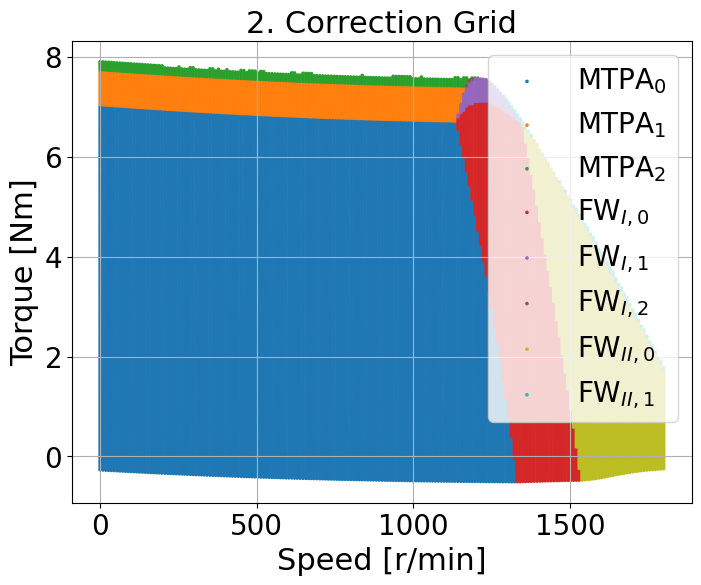

In [4]:
# 2. Correction grid: re-evaluate baseline currents through the trained NTM
#    to obtain the neural-predicted torque at every operating point.
DEVICE = torch.device("cpu")

weights_dir = os.path.join(root_dir, "weights")
MODEL_SAVE_PATH = os.path.join(weights_dir, "NTM_Weights_0344.pth")
SCALER_SAVE_PATH = os.path.join(weights_dir, "NTM_Scaler_0344.npy")
INPUT_SIZE = 5
OPTIMAL_HIDDEN_SIZE = 12

print("Loading trained NeuralTorquePredictor...")
neural_net, scaler = load_neural_model(
    weights_path=MODEL_SAVE_PATH,
    scaler_path=SCALER_SAVE_PATH,
    hidden_size=OPTIMAL_HIDDEN_SIZE,
    input_size=INPUT_SIZE,
    device=DEVICE,
)

neural_model_wrapper = ModelNeural(
    machine=machine,
    flux=flux,
    neural_model=neural_net,
    scaler=scaler,
    device=DEVICE,
)

solver_opts_neural = {"disp": False, "ftol": 1e-5, "maxiter": 2500, "eps": 1e-4}
neural_optimizer = MotorOptimizer(model=neural_model_wrapper, opts=solver_opts_neural)

corr_filename = os.path.join(data_dir, "IEEETIE_machine2_correction_0344.pkl")
if os.path.isfile(corr_filename):
    print(f"Loading existing correction grid from '{corr_filename}'...")
    with open(corr_filename, "rb") as file:
        correction_grid_result = pickle.load(file)
else:
    print("Starting correction grid calculation...")
    correction_grid_result = get_correction_grid(
        dict_grid=grid_result,
        model=neural_model_wrapper,
    )
    with open(corr_filename, "wb") as file:
        pickle.dump(correction_grid_result, file)
    print(f"Correction grid successfully calculated and saved to '{corr_filename}'")

print("Plotting correction grid (neural-predicted torques)...")
correction_machine_data = grid_to_data(correction_grid_result, k_skip=1)
plot_grid_segments(
    correction_machine_data,
    title="2. Correction Grid",
    override_torq_2d=correction_grid_result["grid_torq_neural"],
)

Loading existing recalculated grid from 'c:\Users\matas\Desktop\CurrentSetpoints_main\data\IEEETIE_machine2_recalculated_0344.pkl'...
Plotting recalculated grid...


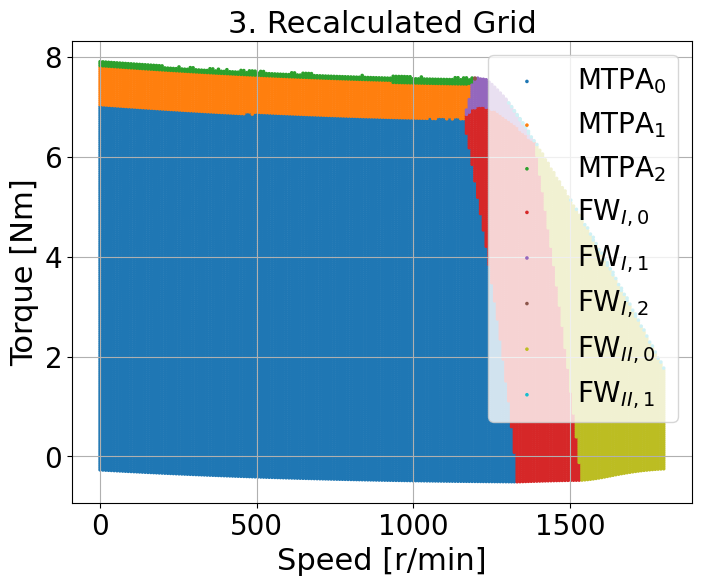

In [5]:
# 3. Recalculated grid: re-run the optimizer with the neural torque model,
#    using baseline currents as warm starts and neural torque as the target.
recalc_filename = os.path.join(data_dir, "IEEETIE_machine2_recalculated_0344.pkl")

if os.path.isfile(recalc_filename):
    print(f"Loading existing recalculated grid from '{recalc_filename}'...")
    with open(recalc_filename, "rb") as file:
        recalc_grid_result = pickle.load(file)
else:
    print(
        "Starting recalculated grid calculation. Using baseline currents as warm starts..."
    )
    recalc_grid_result = calculate_grid(
        optimizer=neural_optimizer,
        transform=transform,
        opts=grid_opts,
        mode="recalculated",
        dict_grid_corr=correction_grid_result,
    )
    with open(recalc_filename, "wb") as file:
        pickle.dump(recalc_grid_result, file)
    print(f"Recalculated grid successfully calculated and saved to '{recalc_filename}'")

print("Plotting recalculated grid...")
recalc_machine_data = grid_to_data(recalc_grid_result, k_skip=1)
plot_grid_segments(
    recalc_machine_data,
    title="3. Recalculated Grid",
    override_torq_2d=recalc_grid_result["grid_torq_neural"],
)

Loading existing compensated neural grid from 'c:\Users\matas\Desktop\CurrentSetpoints_main\data\IEEETIE_machine2_compensated_0344.pkl'...
Plotting compensated neural grid...


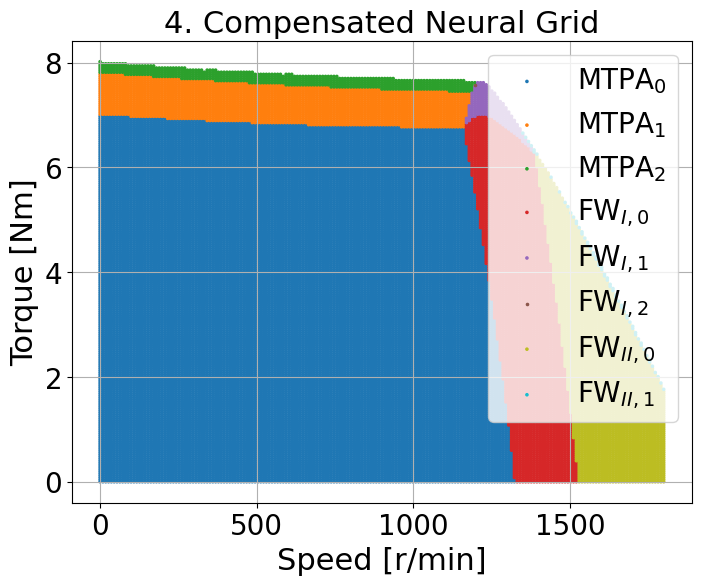

In [6]:
# 4. Compensated neural grid: full optimization with the neural model from
#    scratch (no warm starts from baseline).
neural_filename = os.path.join(data_dir, "IEEETIE_machine2_compensated_0344.pkl")

if os.path.isfile(neural_filename):
    print(f"Loading existing compensated neural grid from '{neural_filename}'...")
    with open(neural_filename, "rb") as file:
        neural_grid_result = pickle.load(file)
else:
    print(
        "Starting compensated neural grid calculation. "
        "This may take longer due to network inference..."
    )
    neural_grid_result = calculate_grid(
        optimizer=neural_optimizer, transform=transform, opts=grid_opts, mode="standard"
    )
    with open(neural_filename, "wb") as file:
        pickle.dump(neural_grid_result, file)
    print(
        f"Compensated neural grid successfully calculated and saved to '{neural_filename}'"
    )

print("Plotting compensated neural grid...")
neural_machine_data = grid_to_data(neural_grid_result, k_skip=1)
plot_grid_segments(neural_machine_data, title="4. Compensated Neural Grid")

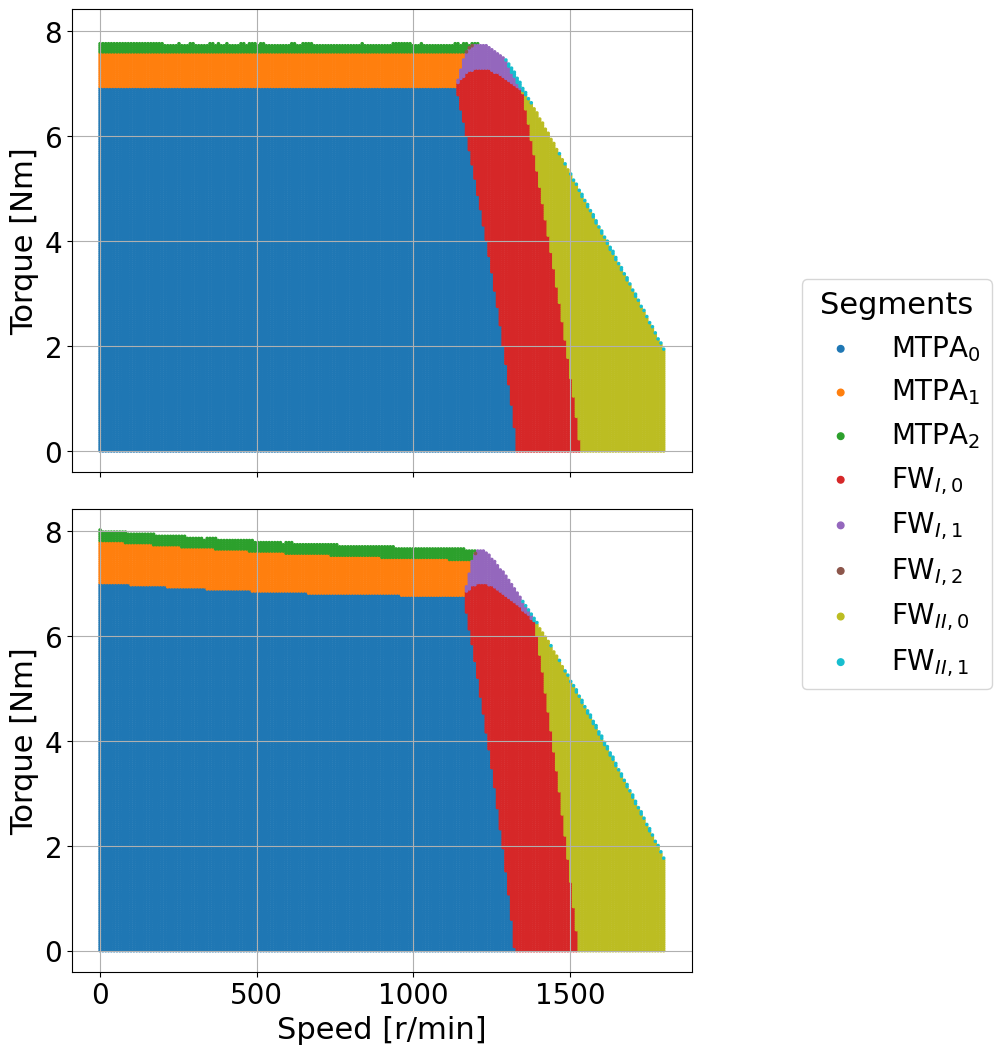

In [7]:
from current_setpoints.utils.plotting import plot_baseline_vs_compensated

# Combined map: baseline (top) vs compensated (bottom), shared Segments legend.
plot_baseline_vs_compensated(machine_data, neural_machine_data)

Loaded 174 valid data points from CSV.
Analytical RMSE (test set, n=27): 0.1581 Nm
Neural     RMSE (test set, n=27): 0.0344 Nm


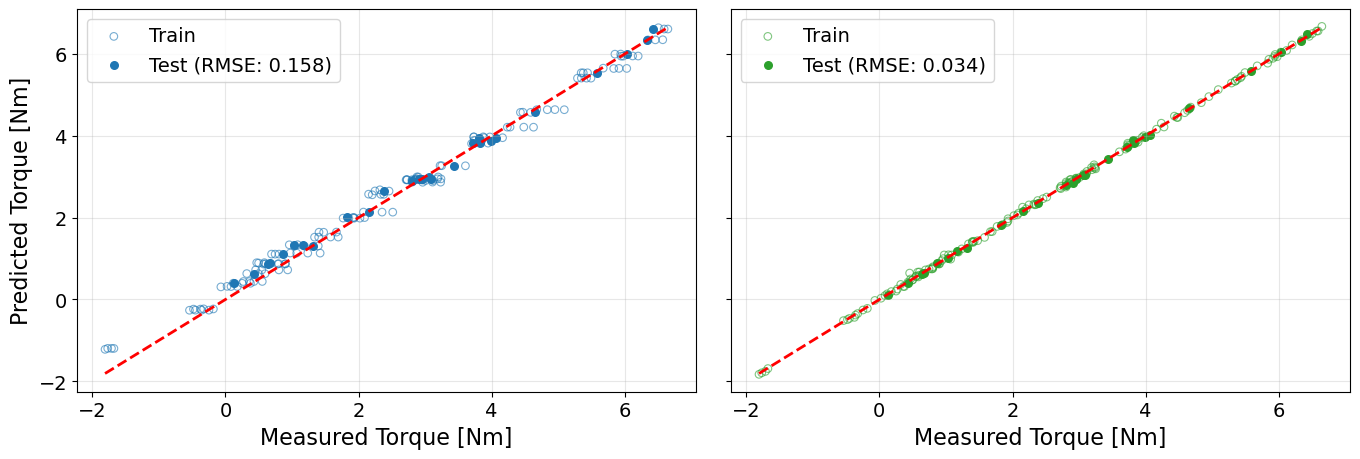

In [8]:
# Global model performance: analytical vs. neural on experimental data.
# RMSE is computed on the held-out test split (matching the train/test
# partition used in model_trainer.ipynb), while the scatter plots show
# both train and test points for context. Train points are drawn hollow,
# test points filled.
import pandas as pd
from sklearn.model_selection import train_test_split

from current_setpoints.utils import load_aggregated_csv_data
from current_setpoints.utils.plotting import plot_global_performance

TEST_SIZE = 0.15
RANDOM_STATE = 42

CSV_PATH = os.path.join(data_dir, "aggregated_file_means.csv")
COL_MAP = {
    "omega": "omega",
    "id1": "id1",
    "iq1": "iq1",
    "id3": "id3",
    "iq3": "iq3",
    "torq": "torq_meas",
}

df_meas = load_aggregated_csv_data(CSV_PATH, COL_MAP)
df_meas = df_meas.reset_index(drop=True)
X_phys = df_meas[["omega", "id1", "iq1", "id3", "iq3"]].to_numpy(dtype=np.float32)

# Predict torque per row through both models. The analytical model's
# calculate_torque is fast; the neural wrapper's calculate_torque returns
# the analytical part PLUS the network residual (the new behavior of
# ModelNeural).
torq_ana_pred = np.zeros(len(X_phys), dtype=np.float64)
torq_neural_pred = np.zeros(len(X_phys), dtype=np.float64)
for i in range(len(X_phys)):
    omega_i = float(X_phys[i, 0])
    i_dq = X_phys[i, 1:].astype(np.float64)
    torq_ana_pred[i] = analytical_model.calculate_torque(omega_i, i_dq)
    torq_neural_pred[i] = neural_model_wrapper.calculate_torque(omega_i, i_dq)

df_meas["torq_Analytical"] = torq_ana_pred
df_meas["torq_Neural"] = torq_neural_pred
df_meas["Error_Analytical"] = df_meas["torq_Analytical"] - df_meas["torq_meas"]
df_meas["Error_Neural"] = df_meas["torq_Neural"] - df_meas["torq_meas"]

indices = np.arange(len(df_meas))
train_idx, test_idx = train_test_split(
    indices, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
test_mask = np.zeros(len(df_meas), dtype=bool)
test_mask[test_idx] = True

rmse_ana_test = np.sqrt(np.mean(df_meas.loc[test_mask, "Error_Analytical"] ** 2))
rmse_nn_test = np.sqrt(np.mean(df_meas.loc[test_mask, "Error_Neural"] ** 2))
print(f"Analytical RMSE (test set, n={test_mask.sum()}): {rmse_ana_test:.4f} Nm")
print(f"Neural     RMSE (test set, n={test_mask.sum()}): {rmse_nn_test:.4f} Nm")

plot_global_performance(
    df_meas, machine, models=["Analytical", "Neural"], test_mask=test_mask
)

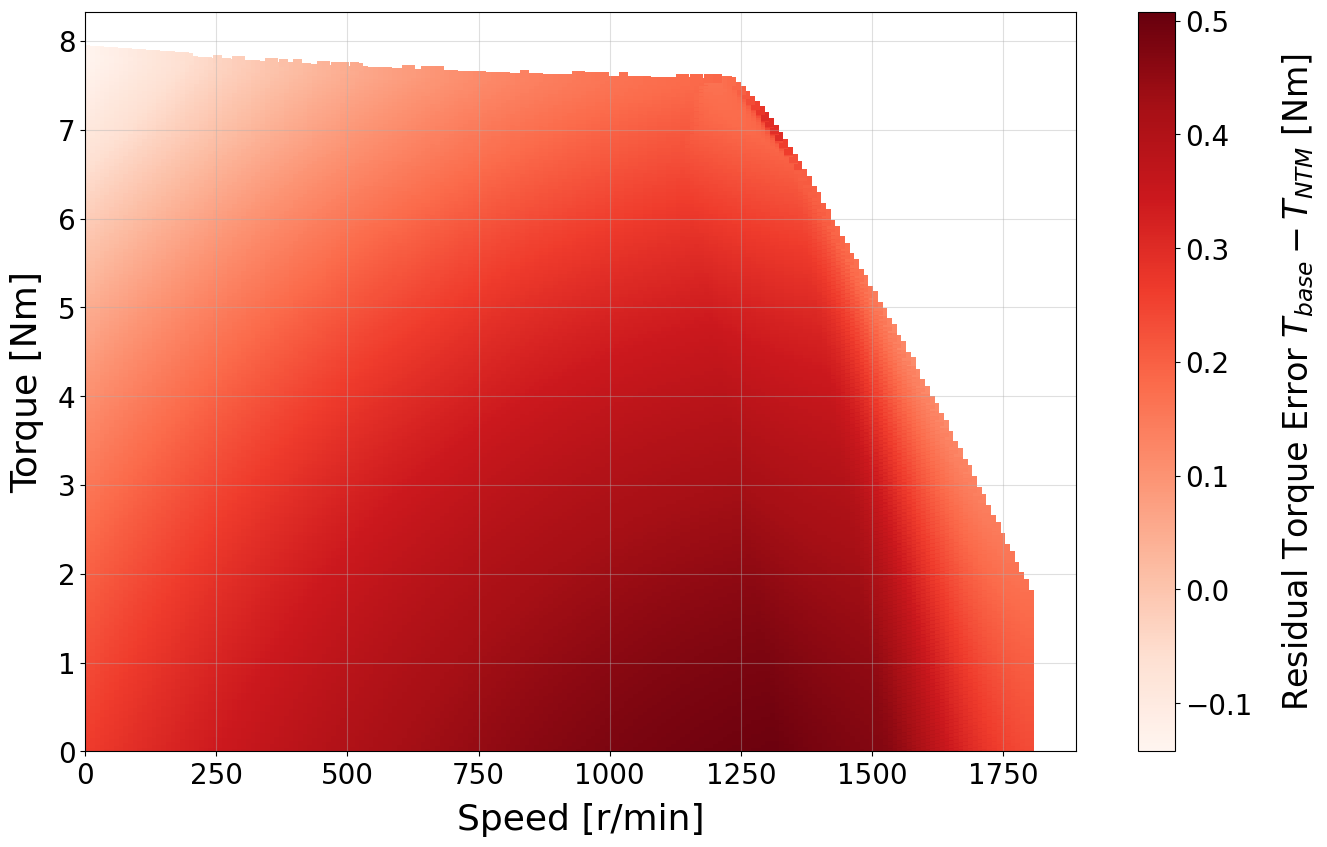

In [9]:
# Torque residual heatmap: target torque - neural-predicted torque on baseline currents.
from current_setpoints.utils.plotting import plot_residual_torque_error

plot_residual_torque_error(correction_grid_result, machine)

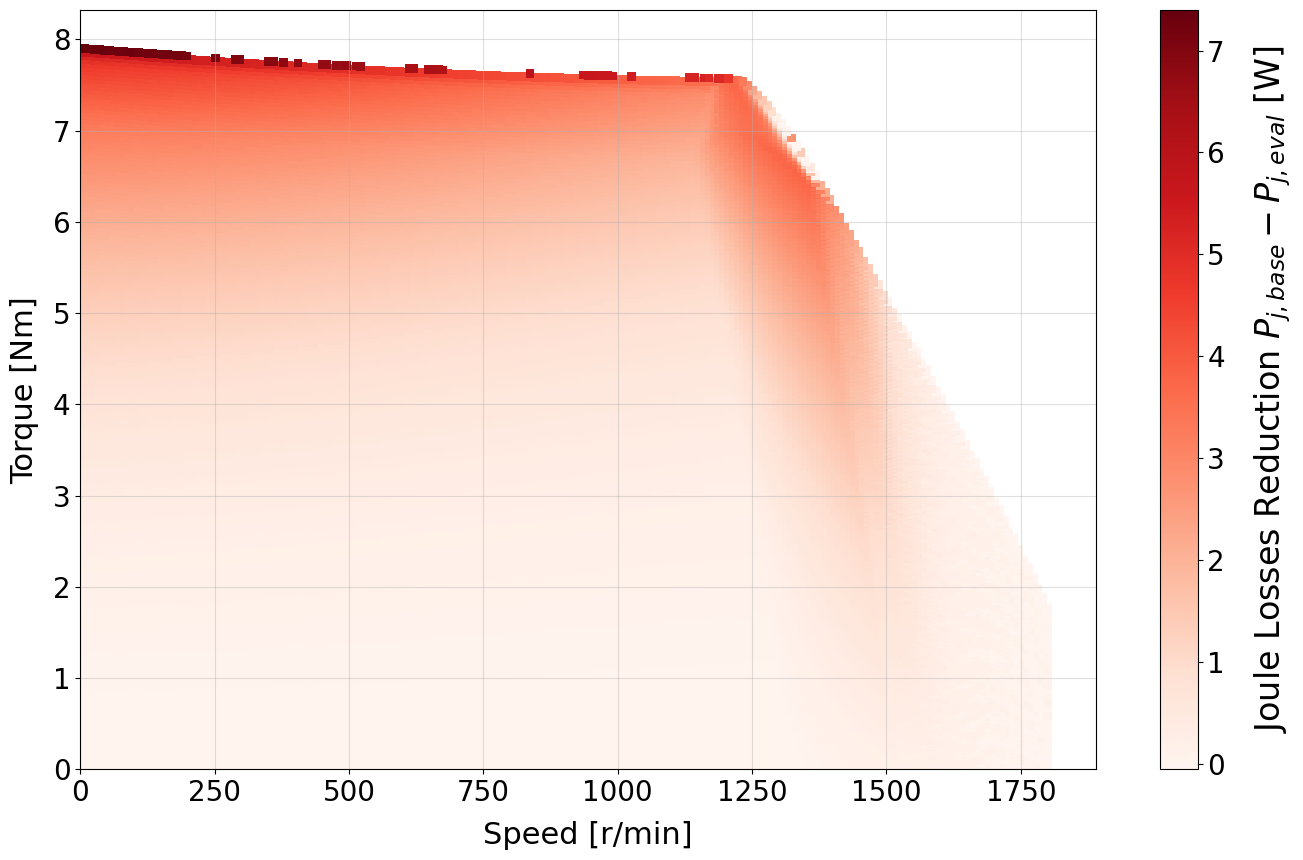

Analysis Complete. Max savings: 7.40 W


In [10]:
# Joule loss reduction: baseline (analytical) vs. recalculated (neural-optimized) currents.
from current_setpoints.utils.plotting import plot_joule_losses_reduction

plot_joule_losses_reduction(correction_grid_result, recalc_grid_result, machine)

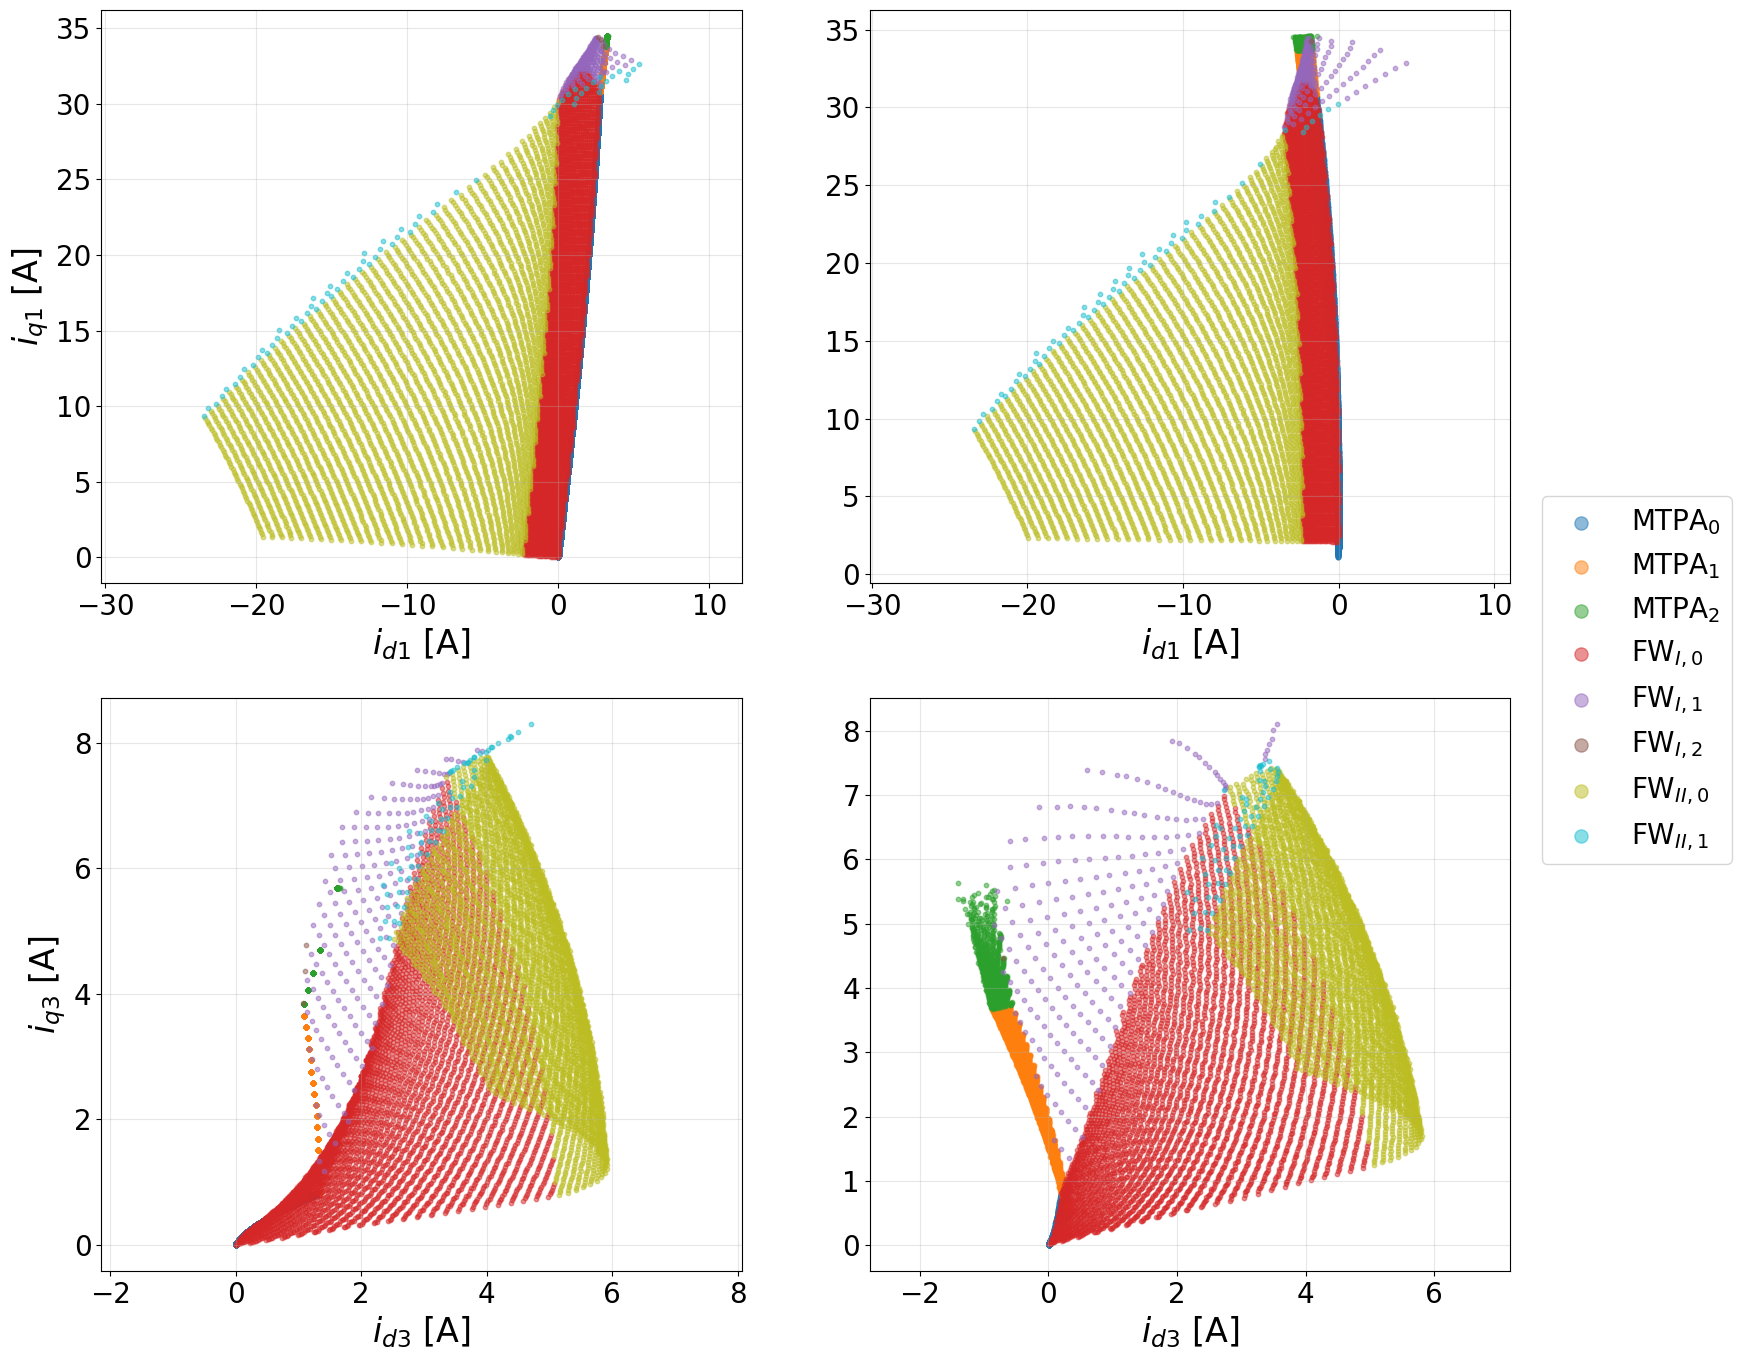

In [11]:
# Current trajectories: baseline (analytical) vs. compensated neural-optimized.
from current_setpoints.utils.plotting import plot_current_trajectories_split

plot_current_trajectories_split(grid_result, neural_grid_result, machine)